# 🔍 RAG Retrieval Evaluation (Elasticsearch)

Evaluates RAG retrieval performance using Elasticsearch with:
- **Dense Vector Search**: Semantic similarity using embeddings
- **BM25 Keyword Search**: Traditional full-text search
- **Hybrid Search**: Combined vector + BM25 (best of both)

## Advantages over separate Chroma + BM25:
- Single index for all strategies (no data duplication)
- Compare strategies side-by-side efficiently
- Native hybrid search support
- Can switch strategies dynamically

## Metrics:
- **Recall@K**: % of ground truth docs found in top-K results
- **MRR**: Mean Reciprocal Rank
- **Popularity Bias**: Whether popular docs are preferred over relevant ones
- **Per-Decile Performance**: Results broken down by popularity tier

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv

from rag.elasticsearch_rag_service import ElasticsearchRagService
from rag.utils import IndexingConfig
from config import DATA_DIR


load_dotenv()

# ============================================================================
# Evaluation Configuration
# ============================================================================

# Elasticsearch Connection
ES_URL = "http://localhost:9200"
ES_USER = os.getenv("ELASTICSEARCH_USERNAME") or None
ES_PASSWORD = os.getenv("ELASTICSEARCH_PASSWORD") or None

# Collection & Index
NAME = "wiki_full"
COLLECTION_NAME = NAME
COLLECTION_ROOT = Path(DATA_DIR) / NAME
QUESTIONS_PATH = COLLECTION_ROOT / "popqa.parquet"

# Embedding Configuration (MUST match indexing settings exactly!)
EMBEDDING_MODEL = "intfloat/multilingual-e5-small"  # Match rag_indexing.ipynb!
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 100

# Retrieval Configuration
STRATEGIES = ["approximation", "bm25"]  # Strategies to evaluate
TOP_K = 10  # Primary metric for reporting (e.g., Recall@10 for popularity decile analysis)
K_VALUES_DETAILED = [1,3,5,10]  # K values for investigation/curves (e.g., 1-20 to see full trend)
MAX_QUESTIONS = None  # Set to limit for testing (e.g., 100), None for all

# kNN Search Configuration
# num_candidates controls how many vectors HNSW explores during approximate search.
# Default in langchain-elasticsearch is 50, which is far too low for large indices.
# Higher = better recall but slower. Recommended: 500-10000 for million-scale indices.
NUM_CANDIDATES = 1000  # Override the pathologically low default of 50

# Output Configuration
OUTPUT_FOLDER = "popqa"  # Folder name for storing all results
RESULTS_DIR = COLLECTION_ROOT / OUTPUT_FOLDER
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Config loaded")
print(f"  Index: {COLLECTION_NAME} @ {ES_URL}")
print(f"  Questions: {QUESTIONS_PATH}")
print(f"  Embedding Model: {EMBEDDING_MODEL}")
print(f"  Top-K (Primary Metric): {TOP_K}")
print(f"  K-Values for Investigation: {list(K_VALUES_DETAILED)}")
print(f"  kNN num_candidates: {NUM_CANDIDATES}")
print(f"  Will retrieve: {max(TOP_K, max(K_VALUES_DETAILED))} documents per query")
print(f"  Results: {RESULTS_DIR}")

✓ Config loaded
  Index: wiki_full @ http://localhost:9200
  Questions: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/popqa.parquet
  Embedding Model: intfloat/multilingual-e5-small
  Top-K (Primary Metric): 10
  K-Values for Investigation: [1, 3, 5, 10]
  kNN num_candidates: 1000
  Will retrieve: 10 documents per query
  Results: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/popqa


In [2]:
# ============================================================================
# Load Questions
# ============================================================================

print("Loading questions...")
qa_df = pd.read_parquet(QUESTIONS_PATH)

qa_df = qa_df.dropna(subset=["question_text"])

# Normalize Wikipedia IDs to string format for matching
qa_df["wikipedia_id"] = qa_df["wikipedia_id"].astype(str).str.strip()

# Limit for testing if specified
if MAX_QUESTIONS:
    qa_df = qa_df.sample(n=min(MAX_QUESTIONS, len(qa_df)), random_state=42)
    print(f"  Limited to {len(qa_df)} questions for testing")

print(f"✓ Loaded {len(qa_df):,} questions")
print(f"  Unique docs: {qa_df['wikipedia_id'].nunique():,}")
print(f"  Datasets: {qa_df['dataset'].value_counts().to_dict() if 'dataset' in qa_df.columns else 'N/A'}")

# Display sample
print("\nSample questions:")
display(qa_df.head(3))

Loading questions...
✓ Loaded 2,805 questions
  Unique docs: 2,752
  Datasets: {'popqa': 2805}

Sample questions:


,question_id,question_text,answer_texts,wikipedia_id,wikipedia_title,popularity_avg,popularity_rank,dataset,is_synthetic,decile
0,333336,What is the capital of canton of Mirambeau?,[Mirambeau],10431292,Canton of Mirambeau,5.416667,5.366038e+06,popqa,False,0
1,296572,In what city was Jiří Vyčichlo born?,[Prague],41733828,Jiří Vyčichlo,4.964015,5.418471e+06,popqa,False,0
2,4664979,In what country is Jeqjeq-e Pain?,[Iran],23434401,Jeqjeq-e Pain,3.269697,5.610422e+06,popqa,False,0


In [3]:
# ============================================================================
# Load RAG Index
# ============================================================================

print("Connecting to Elasticsearch index...")

config = IndexingConfig(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    embedding_provider="huggingface",
    embedding_model=EMBEDDING_MODEL,
    trust_remote_code=True,
    use_progress=False
)

# Initialize service (strategy doesn't matter for loading, we'll override at query time)
service = ElasticsearchRagService(
    config=config,
    es_url=ES_URL,
    es_user=ES_USER,
    es_password=ES_PASSWORD,
    strategy="hybrid"
)

service.load_index(COLLECTION_NAME)


print(f"✓ Connected to Elasticsearch index: {COLLECTION_NAME}")

Connecting to Elasticsearch index...
✓ Connected to Elasticsearch index: wiki_full


In [ ]:
# ============================================================================
# Run Retrieval for All Strategies
# ============================================================================

print("Running retrieval for all strategies...\n")

results_by_strategy = {}

for strategy in STRATEGIES:
    print(f"{'='*60}")
    print(f"Strategy: {strategy.upper()}")
    print(f"{'='*60}")
    
    # Only use num_candidates for vector/hybrid strategies (irrelevant for BM25)
    nc = NUM_CANDIDATES if strategy in ("approximation", "hybrid") else None
    
    # Run batch retrieval with this strategy
    all_results = service.batch_retrieve(
        questions=qa_df["question_text"].tolist(),
        top_k=max(TOP_K, max(K_VALUES_DETAILED)),  # Retrieve enough for both primary and investigation
        strategy=strategy,
        num_candidates=nc,
    )
    
    # Process results
    rows = []
    for idx, (question_row, retrieved_docs) in enumerate(zip(qa_df.itertuples(), all_results)):
        expected_id = str(question_row.wikipedia_id).strip()
        
        # Extract retrieved doc IDs
        retrieved_ids = []
        retrieved_scores = []
        retrieved_popularities = []
        
        for doc, score in retrieved_docs:
            raw_id = doc.metadata.get("wikipedia_id", doc.metadata.get("id", ""))
            doc_id = str(int(float(raw_id))) if raw_id not in (None, "") else ""
            retrieved_ids.append(doc_id)
            retrieved_scores.append(score)
            retrieved_popularities.append(doc.metadata.get("popularity_avg"))
        
        rows.append({
            "question": question_row.question_text,
            "wikipedia_id": expected_id,
            "wikipedia_title": getattr(question_row, "wikipedia_title", None),
            "decile": getattr(question_row, "decile", -1),
            "popularity_avg": getattr(question_row, "popularity_avg", None),
            "dataset": getattr(question_row, "dataset", None),
            "topk_ids": retrieved_ids,
            "topk_scores": retrieved_scores,
            "topk_popularities": retrieved_popularities,
        })
    
    results_df = pd.DataFrame(rows)
    # Add pop_decile column immediately for later use
    results_df['pop_decile'] = results_df['decile']
    results_by_strategy[strategy] = results_df
    
    print(f"✓ Retrieved {len(results_df)} queries\n")

# Update STRATEGIES list to include all tested configurations
ALL_STRATEGIES = list(results_by_strategy.keys())
print(f"✅ All retrieval complete! Tested {len(ALL_STRATEGIES)} configurations:")
print(f"   {', '.join(ALL_STRATEGIES)}")

Running retrieval for all strategies...

Strategy: APPROXIMATION


Retrieving (approximation):   3%|▎         | 74/2805 [01:51<1:04:20,  1.41s/q]

In [ ]:
# ============================================================================
# Compute Metrics for All Strategies
# ============================================================================

def compute_metrics(results_df, k_values=K_VALUES_DETAILED):
    """Compute retrieval metrics."""
    metrics = {}
    
    # Calculate Recall@K
    for k in k_values:
        def recall_at_k(row):
            topk = row["topk_ids"][:k] if len(row["topk_ids"]) >= k else row["topk_ids"]
            return 1.0 if row["wikipedia_id"] in topk else 0.0
        
        results_df[f"recall@{k}"] = results_df.apply(recall_at_k, axis=1)
        metrics[f"recall@{k}"] = results_df[f"recall@{k}"].mean()
    
    # Calculate MRR (Mean Reciprocal Rank)
    def get_reciprocal_rank(row):
        try:
            rank = row["topk_ids"].index(row["wikipedia_id"]) + 1
            return 1.0 / rank
        except (ValueError, AttributeError):
            return 0.0
    
    results_df["reciprocal_rank"] = results_df.apply(get_reciprocal_rank, axis=1)
    metrics["mrr"] = results_df["reciprocal_rank"].mean()
    
    # Calculate rank statistics
    def get_rank(row):
        try:
            return row["topk_ids"].index(row["wikipedia_id"]) + 1
        except (ValueError, AttributeError):
            return None
    
    results_df["rank"] = results_df.apply(get_rank, axis=1)
    found_ranks = results_df["rank"].dropna()
    metrics["median_rank"] = found_ranks.median() if len(found_ranks) > 0 else None
    metrics["mean_rank"] = found_ranks.mean() if len(found_ranks) > 0 else None
    
    return metrics, results_df

print("Computing metrics for all strategies...\n")

# Compute metrics for ALL k values needed (both primary and investigation)
k_values_full = list(range(1, max(TOP_K, max(K_VALUES_DETAILED)) + 1))

metrics_by_strategy = {}
for strategy, results_df in results_by_strategy.items():
    metrics, results_df_with_metrics = compute_metrics(results_df, k_values_full)
    metrics_by_strategy[strategy] = metrics
    results_by_strategy[strategy] = results_df_with_metrics  # Update with metrics
    
    print(f"{'='*60}")
    print(f"{strategy.upper()} METRICS")
    print(f"{'='*60}")
    # Show detailed k values for investigation
    for k in K_VALUES_DETAILED:
        print(f"  recall@{k}: {metrics[f'recall@{k}']:.4f}")
    # Show primary metric if not already in detailed list
    if TOP_K not in K_VALUES_DETAILED:
        print(f"  recall@{TOP_K} (PRIMARY): {metrics[f'recall@{TOP_K}']:.4f}")
    print(f"  mrr: {metrics['mrr']:.4f}")
    if metrics["median_rank"] is not None:
        print(f"  median_rank: {metrics['median_rank']:.4f}")
    if metrics["mean_rank"] is not None:
        print(f"  mean_rank: {metrics['mean_rank']:.4f}")
    print()

# Save metrics
metrics_df = pd.DataFrame(metrics_by_strategy).T
metrics_path = RESULTS_DIR / "metrics_comparison.csv"
metrics_df.to_csv(metrics_path)
print(f"✓ Saved metrics to {metrics_path}")

ALL_STRATEGIES = list(results_by_strategy.keys())
# Update ALL_STRATEGIES for use in visualizations

Computing metrics for all strategies...

APPROXIMATION METRICS
  recall@1: 0.4038
  recall@3: 0.5463
  recall@5: 0.5708
  recall@10: 0.5708
  mrr: 0.4709
  median_rank: 1.0000
  mean_rank: 1.4870

BM25 METRICS
  recall@1: 0.2509
  recall@3: 0.4038
  recall@5: 0.4344
  recall@10: 0.4344
  mrr: 0.3260
  median_rank: 1.0000
  mean_rank: 1.6881

✓ Saved metrics to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/metrics_comparison.csv


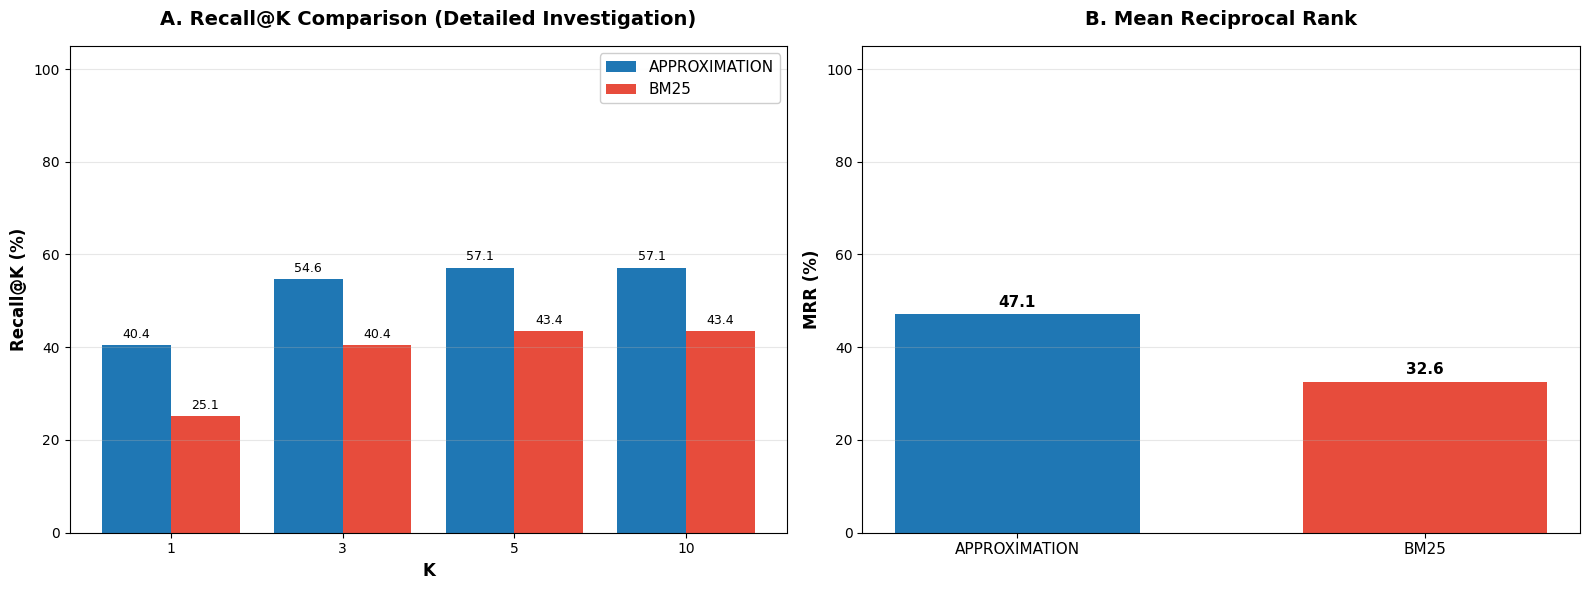

✓ Saved performance overview to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/performance_overview.png


In [ ]:
# ============================================================================
# Performance Overview: Recall & MRR Across Strategies
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Recall@K Comparison
ax = axes[0]
x = np.arange(len(K_VALUES_DETAILED))
width = 0.8 / len(ALL_STRATEGIES)
strategy_colors = {'vector': '#3498db', 'bm25': '#e74c3c', 'hybrid': '#27ae60'}

for i, strategy in enumerate(ALL_STRATEGIES):
    recalls = [metrics_by_strategy[strategy][f"recall@{k}"] for k in K_VALUES_DETAILED]
    color = strategy_colors.get(strategy, plt.cm.tab10.colors[i])
    bars = ax.bar(x + i*width, np.array(recalls) * 100, width, label=strategy.upper(), color=color)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall@K (%)', fontsize=12, fontweight='bold')
ax.set_title('A. Recall@K Comparison (Detailed Investigation)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * (len(ALL_STRATEGIES)-1) / 2)
ax.set_xticklabels(K_VALUES_DETAILED)
ax.legend(fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

# Panel B: MRR Comparison
ax = axes[1]
mrr_values = [metrics_by_strategy[s]["mrr"] * 100 for s in ALL_STRATEGIES]
colors = [strategy_colors.get(s, plt.cm.tab10.colors[i]) for i, s in enumerate(ALL_STRATEGIES)]
bars = ax.bar(range(len(ALL_STRATEGIES)), mrr_values, color=colors, width=0.6)

# Add value labels
for bar, val in zip(bars, mrr_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('MRR (%)', fontsize=12, fontweight='bold')
ax.set_title('B. Mean Reciprocal Rank', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(ALL_STRATEGIES)))
ax.set_xticklabels([s.upper() for s in ALL_STRATEGIES], fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "performance_overview.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved performance overview to {RESULTS_DIR / 'performance_overview.png'}")

Analyzing per-decile performance...

APPROXIMATION - Per-Decile Performance:
   decile  count       mrr
0       0     28  0.392857
1       1     10  0.258333
2       2     25  0.393333
3       3     43  0.418605
4       4     90  0.319444
5       5    148  0.426802
6       6    200  0.469167
7       7    200  0.517500
8       8    200  0.516250
9       9    200  0.523750

BM25 - Per-Decile Performance:
   decile  count       mrr
0       0     28  0.276786
1       1     10  0.250000
2       2     25  0.163333
3       3     43  0.286822
4       4     90  0.274074
5       5    148  0.324324
6       6    200  0.358333
7       7    200  0.358750
8       8    200  0.379583
9       9    200  0.271250



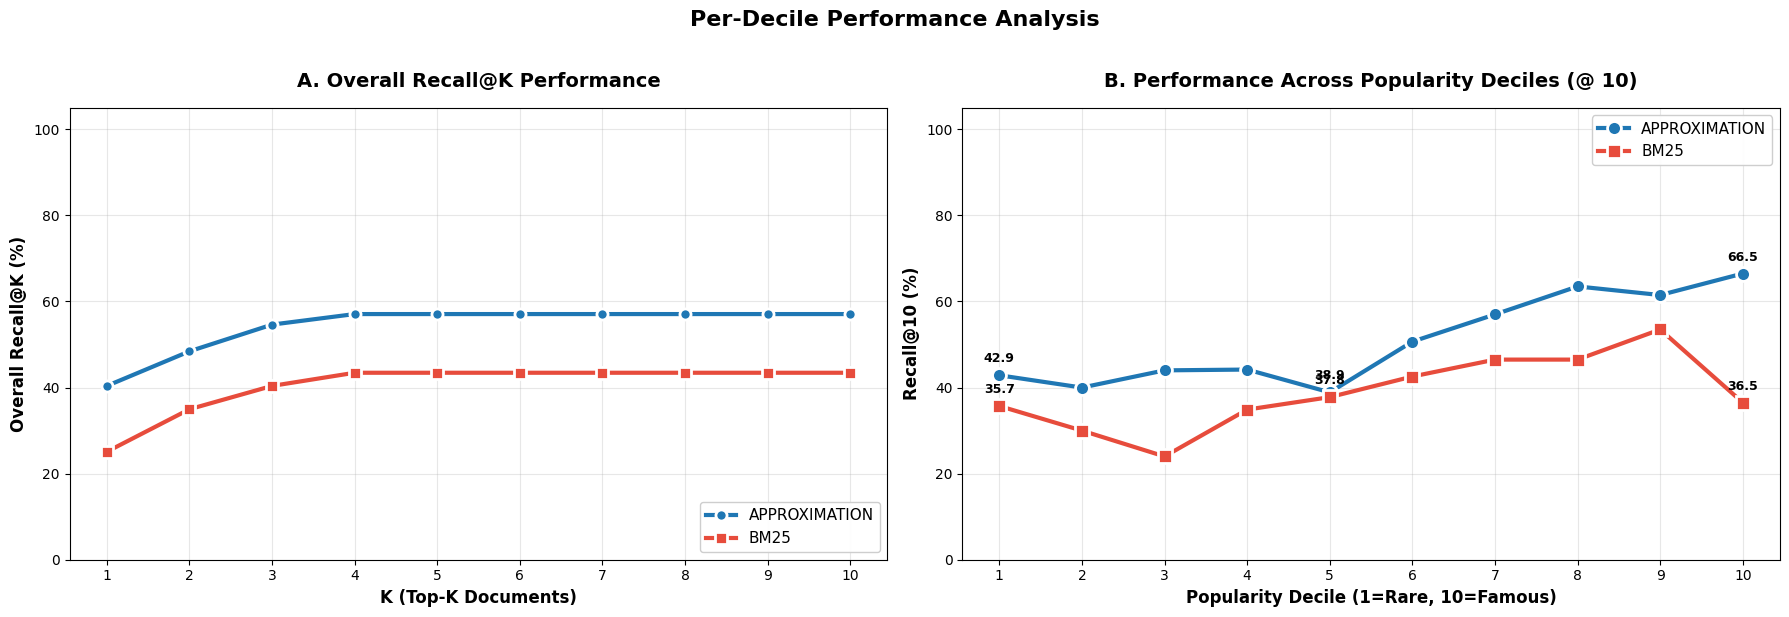

✓ Saved per-decile performance to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/per_decile_performance.png


In [ ]:
# ============================================================================
# Per-Decile Performance Analysis
# ============================================================================

print("Analyzing per-decile performance...\n")

# Compute per-decile metrics for each strategy - calculate for all needed k values
decile_metrics_by_strategy = {}
k_range_full = list(range(1, max(TOP_K, max(K_VALUES_DETAILED)) + 1))

for strategy in ALL_STRATEGIES:
    results_df = results_by_strategy[strategy]
    valid_results = results_df[results_df["decile"] >= 0]
    
    decile_metrics = []
    for decile in range(10):
        decile_data = valid_results[valid_results["decile"] == decile]
        if len(decile_data) == 0:
            continue
        
        metrics_row = {"decile": decile, "count": len(decile_data)}
        # Calculate recall for ALL k values
        for k in k_range_full:
            metrics_row[f"recall@{k}"] = decile_data[f"recall@{k}"].mean()
        metrics_row["mrr"] = decile_data["reciprocal_rank"].mean()
        
        decile_metrics.append(metrics_row)
    
    decile_metrics_by_strategy[strategy] = pd.DataFrame(decile_metrics)
    
    print(f"{strategy.upper()} - Per-Decile Performance:")
    print(decile_metrics_by_strategy[strategy][["decile", "count", "mrr"]])
    print()

# Create combined visualization: one graph for performance across strategies
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

strategy_colors = {'vector': '#3498db', 'bm25': '#e74c3c', 'hybrid': '#27ae60'}
markers = {'vector': 'o', 'bm25': 's', 'hybrid': 'D'}

# Panel A: Overall Recall@K curves (FIXED - now uses overall metrics, not per-decile average)
ax = axes[0]
for strategy in ALL_STRATEGIES:
    # Use the OVERALL recall metrics (same as cell 6)
    recall_by_k = [metrics_by_strategy[strategy][f"recall@{k}"] * 100 for k in k_range_full]
    
    color = strategy_colors.get(strategy, plt.cm.tab10.colors[ALL_STRATEGIES.index(strategy)])
    marker = markers.get(strategy, 'o')
    ax.plot(k_range_full, recall_by_k, marker=marker, linewidth=3, markersize=8, 
            color=color, label=strategy.upper(), markeredgewidth=2, markeredgecolor='white')

ax.set_xlabel('K (Top-K Documents)', fontsize=12, fontweight='bold')
ax.set_ylabel('Overall Recall@K (%)', fontsize=12, fontweight='bold')
ax.set_title('A. Overall Recall@K Performance', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax.set_xticks(k_range_full)
ax.set_ylim(0, 105)

# Panel B: Recall@TOP_K across different popularity deciles for both strategies
ax = axes[1]
for strategy in ALL_STRATEGIES:
    decile_df = decile_metrics_by_strategy[strategy]
    recall_by_decile = decile_df[f"recall@{TOP_K}"] * 100
    
    color = strategy_colors.get(strategy, plt.cm.tab10.colors[ALL_STRATEGIES.index(strategy)])
    marker = markers.get(strategy, 'o')
    ax.plot(decile_df["decile"] + 1, recall_by_decile, marker=marker, linewidth=3, markersize=10, 
            color=color, label=strategy.upper(), markeredgewidth=2, markeredgecolor='white')
    
    # Add value labels for key points
    for x, y in zip(decile_df["decile"] + 1, recall_by_decile):
        if x in [1, 5, 10]:  # Label only first, middle, and last
            ax.text(x, y + 3, f'{y:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Popularity Decile (1=Rare, 10=Famous)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Recall@{TOP_K} (%)', fontsize=12, fontweight='bold')
ax.set_title(f'B. Performance Across Popularity Deciles (@ {TOP_K})', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 105)

plt.suptitle("Per-Decile Performance Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_decile_performance.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved per-decile performance to {RESULTS_DIR / 'per_decile_performance.png'}")

In [ ]:
# ============================================================================
# Save All Results
# ============================================================================

print("Saving detailed results...")

for strategy in ALL_STRATEGIES:
    results_df = results_by_strategy[strategy]
    output_path = RESULTS_DIR / f"results_{strategy}.parquet"
    results_df.to_parquet(output_path)
    print(f"  Saved {strategy} results to {output_path}")

# Save per-decile metrics
for strategy, decile_df in decile_metrics_by_strategy.items():
    output_path = RESULTS_DIR / f"per_decile_{strategy}.csv"
    decile_df.to_csv(output_path, index=False)
    print(f"  Saved {strategy} per-decile to {output_path}")

print("\n✅ EVALUATION COMPLETE!")
print(f"\nResults saved to: {RESULTS_DIR}")
print("\nKey Findings:")
print("=" * 60)
for strategy in ALL_STRATEGIES:
    metrics = metrics_by_strategy[strategy]
    print(f"\n{strategy.replace('_', ' ').upper()}:")
    print(f"  Recall@1: {metrics['recall@1']:.4f}")
    print(f"  Recall@{TOP_K} (PRIMARY): {metrics[f'recall@{TOP_K}']:.4f}")
    print(f"  MRR: {metrics['mrr']:.4f}")

Saving detailed results...
  Saved approximation results to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/results_approximation.parquet
  Saved bm25 results to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/results_bm25.parquet
  Saved approximation per-decile to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/per_decile_approximation.csv
  Saved bm25 per-decile to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/per_decile_bm25.csv

✅ EVALUATION COMPLETE!

Results saved to: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results

Key Findings:

APPROXIMATION:
  Recall@1: 0.4038
  Recall@10 (PRIMARY): 0.5708
  MRR: 0.4709

BM25:
  Recall@1: 0.2509
  Recall@10 (PRIMARY): 0.4344
  MRR: 0.3260


In [ ]:
# ============================================================================
# Prepare Data for Advanced Visualizations
# ============================================================================

print("Preparing data for advanced visualizations...")

# Helper functions
def get_found_rank(row):
    try:
        return row["topk_ids"].index(row["wikipedia_id"]) + 1
    except (ValueError, AttributeError):
        return None

def get_wrong_pops(row):
    wrong_pops = []
    for i, doc_id in enumerate(row["topk_ids"]):
        if doc_id != row["wikipedia_id"] and i < len(row["topk_popularities"]):
            if row["topk_popularities"][i] is not None:
                wrong_pops.append(row["topk_popularities"][i])
    return wrong_pops if wrong_pops else None

# Process ALL strategy dataframes once
for strategy_name in ALL_STRATEGIES:
    df = results_by_strategy[strategy_name]
    
    if 'pop_decile' not in df.columns and 'decile' in df.columns:
        df['pop_decile'] = df['decile']
    
    if 'found_at_rank' not in df.columns:
        df["found_at_rank"] = df.apply(get_found_rank, axis=1)
    
    if 'wrong_docs_popularities' not in df.columns:
        df["wrong_docs_popularities"] = df.apply(get_wrong_pops, axis=1)
    
    results_by_strategy[strategy_name] = df

# Calculate corpus bin edges for decile mapping
print("  Calculating corpus decile boundaries...")
all_pops = []
for strategy_df in results_by_strategy.values():
    for pops_list in strategy_df["topk_popularities"]:
        if pops_list:
            all_pops.extend([p for p in pops_list if p is not None and p >= 0])

corpus_bin_edges = np.percentile(all_pops, np.linspace(0, 100, 11)) if all_pops else np.linspace(0, 1, 11)

print(f"✓ Data prepared for {len(ALL_STRATEGIES)} strategies")


Preparing data for advanced visualizations...
  Calculating corpus decile boundaries...
✓ Data prepared for 2 strategies


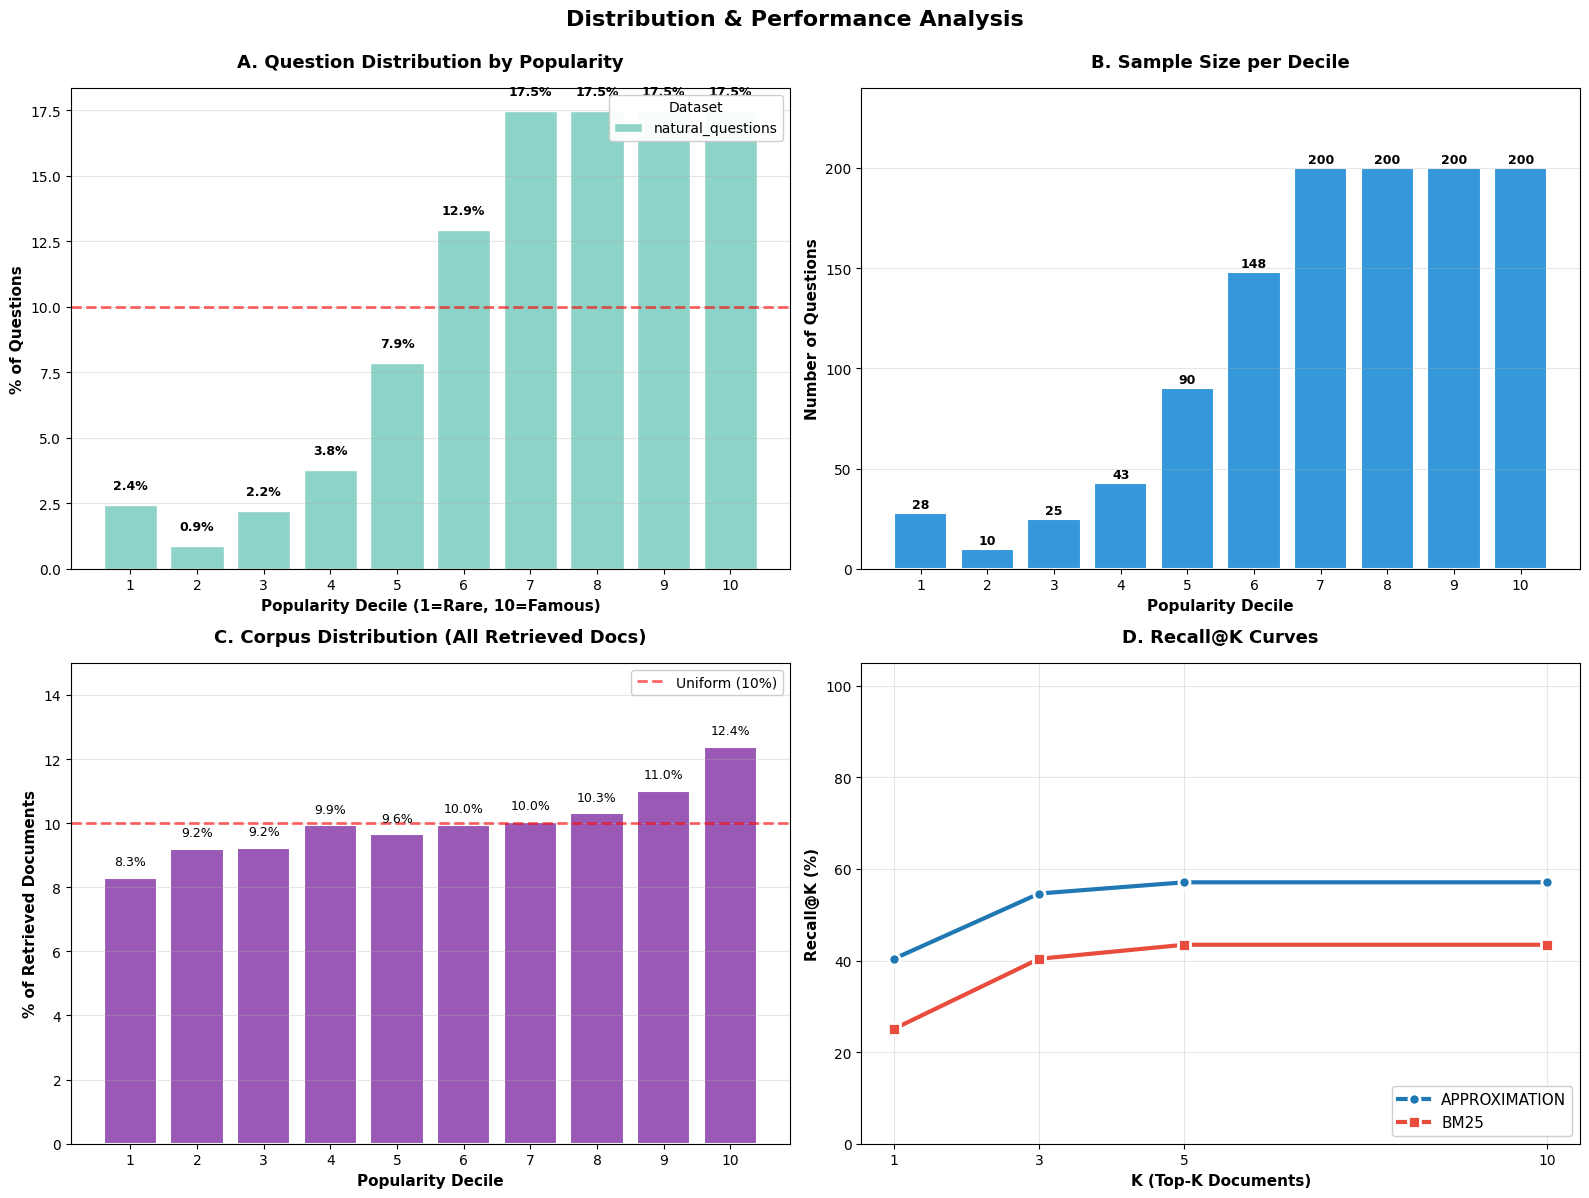

✓ Saved distribution analysis to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/distribution_analysis.png


In [ ]:
# ============================================================================
# Distribution Analysis: Questions & Retrieved Documents
# ============================================================================

# Use first strategy's results for distribution analysis
results_df = results_by_strategy[ALL_STRATEGIES[0]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel A: Question Distribution by Popularity Decile
ax = axes[0, 0]
if "dataset" in results_df.columns:
    datasets = sorted(results_df["dataset"].dropna().unique())
    bottoms = np.zeros(10)
    colors = plt.cm.Set3.colors
    
    for i, ds in enumerate(datasets):
        ds_counts = results_df[results_df["dataset"] == ds]["pop_decile"].value_counts().reindex(range(10), fill_value=0)
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(np.arange(1, 11), ds_pcts.values, bottom=bottoms, color=colors[i % len(colors)],
               edgecolor='white', linewidth=1.0, label=ds)
        bottoms += ds_pcts.values
    
    for i, total in enumerate(bottoms):
        if total > 0.5:
            ax.text(i + 1, total + 0.5, f'{total:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95, title="Dataset")
else:
    q_counts = results_df['pop_decile'].value_counts().sort_index()
    q_pcts = (q_counts / len(results_df)) * 100
    ax.bar(np.arange(1, 11), q_pcts.values, color='#3498db', edgecolor='white', linewidth=1.5)
    for i, val in enumerate(q_pcts.values):
        if val > 0.5:
            ax.text(i + 1, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile (1=Rare, 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title("A. Question Distribution by Popularity", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# Panel B: Sample Size by Decile
ax = axes[0, 1]
sample_sizes = results_df.groupby("pop_decile").size().reindex(range(10), fill_value=0)
bars = ax.bar(np.arange(1, 11), sample_sizes.values, color='#3498db', edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, sample_sizes.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Number of Questions", fontsize=11, fontweight='bold')
ax.set_title("B. Sample Size per Decile", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, sample_sizes.max() * 1.2 if sample_sizes.max() > 0 else 10)

# Panel C: Corpus Distribution (Retrieved Documents)
ax = axes[1, 0]
all_retrieved_pops = []
for pops_list in results_df["topk_popularities"]:
    if pops_list:
        all_retrieved_pops.extend([p for p in pops_list if p is not None and p >= 0])

if all_retrieved_pops:
    corpus_deciles = pd.cut(all_retrieved_pops, bins=corpus_bin_edges, labels=False, include_lowest=True)
    corpus_counts = pd.Series(corpus_deciles).value_counts().sort_index()
    corpus_pcts = (corpus_counts / len(corpus_deciles)) * 100
    
    bars = ax.bar(np.arange(1, 11), corpus_pcts.reindex(range(10), fill_value=0).values, 
                  color='#9b59b6', edgecolor='white', linewidth=1.5)
    
    for i, val in enumerate(corpus_pcts.reindex(range(10), fill_value=0).values):
        if val > 0.5:
            ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Retrieved Documents", fontsize=11, fontweight='bold')
ax.set_title("C. Corpus Distribution (All Retrieved Docs)", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 15)

# Panel D: Recall@K Curves for All Strategies (using full TOP_K range)
ax = axes[1, 1]
k_range = K_VALUES_DETAILED
strategy_colors = {'vector': '#3498db', 'bm25': '#e74c3c', 'hybrid': '#27ae60'}
markers = {'vector': 'o', 'bm25': 's', 'hybrid': 'D'}

for strategy in ALL_STRATEGIES:
    strategy_df = results_by_strategy[strategy]
    recall_curve = []
    for k in k_range:
        recall_k = ((strategy_df["found_at_rank"].notna()) & (strategy_df["found_at_rank"] <= k)).mean()
        recall_curve.append(recall_k * 100)
    
    color = strategy_colors.get(strategy, plt.cm.tab10.colors[ALL_STRATEGIES.index(strategy)])
    marker = markers.get(strategy, 'o')
    ax.plot(k_range, recall_curve, marker=marker, linewidth=3, markersize=8, 
            color=color, label=strategy.upper(), markeredgewidth=2, markeredgecolor='white')

ax.set_xlabel("K (Top-K Documents)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall@K (%)", fontsize=11, fontweight='bold')
ax.set_title("D. Recall@K Curves", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax.set_xticks(k_range)
ax.set_ylim(0, 105)

plt.suptitle("Distribution & Performance Analysis", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "distribution_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved distribution analysis to {RESULTS_DIR / 'distribution_analysis.png'}")

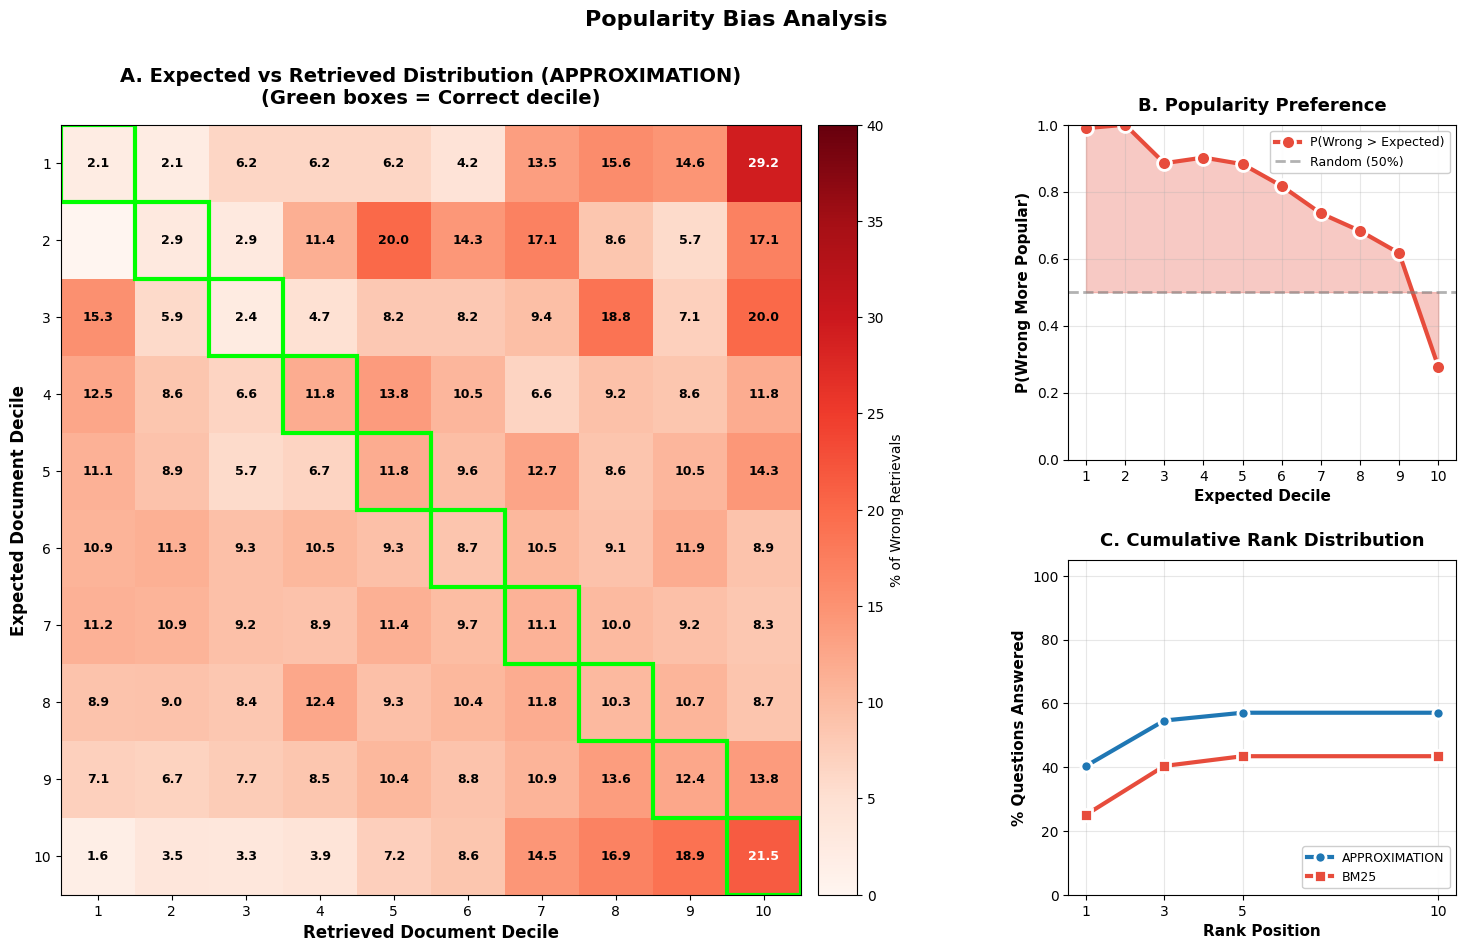

✓ Saved popularity bias analysis to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/popularity_bias_analysis.png


In [ ]:
# ============================================================================
# Popularity Bias Analysis: Expected vs Retrieved Documents
# ============================================================================

# Select first strategy for detailed bias analysis
analysis_strategy = ALL_STRATEGIES[0]
analysis_df = results_by_strategy[analysis_strategy]

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Panel A: Expected vs Retrieved Heatmap (Large)
ax_heat = fig.add_subplot(gs[:, 0:2])
heatmap_data = np.zeros((10, 10))

for _, row in analysis_df.iterrows():
    expected_dec = int(row['pop_decile'])
    wrong_pops = row['wrong_docs_popularities']
    if wrong_pops:
        for wp in wrong_pops:
            wrong_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
            if not pd.isna(wrong_dec):
                heatmap_data[expected_dec, int(wrong_dec)] += 1

row_sums = heatmap_data.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_pct = heatmap_data / row_sums * 100

im = ax_heat.imshow(heatmap_pct, aspect='auto', cmap="Reds", vmin=0, vmax=40)
cbar = plt.colorbar(im, ax=ax_heat, label='% of Wrong Retrievals', pad=0.02)
cbar.ax.tick_params(labelsize=10)

# Add values to heatmap cells
for i in range(10):
    for j in range(10):
        if heatmap_pct[i, j] > 1:
            text_color = 'white' if heatmap_pct[i, j] > 20 else 'black'
            ax_heat.text(j, i, f'{heatmap_pct[i, j]:.1f}', 
                        ha='center', va='center', color=text_color, fontsize=9, fontweight='bold')

# Highlight diagonal
for i in range(10):
    ax_heat.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='lime', linewidth=3))

ax_heat.set_xlabel("Retrieved Document Decile", fontsize=12, fontweight='bold')
ax_heat.set_ylabel("Expected Document Decile", fontsize=12, fontweight='bold')
ax_heat.set_title(f"A. Expected vs Retrieved Distribution ({analysis_strategy.upper()})\n(Green boxes = Correct decile)", 
                  fontsize=14, fontweight='bold', pad=15)
ax_heat.set_xticks(range(10))
ax_heat.set_yticks(range(10))
ax_heat.set_xticklabels(range(1, 11), fontsize=10)
ax_heat.set_yticklabels(range(1, 11), fontsize=10)

# Panel B: Popularity Preference
ax_pref = fig.add_subplot(gs[0, 2])

popularity_bias = []
for d in range(10):
    subset = analysis_df[analysis_df["pop_decile"] == d]
    num_higher = 0
    num_total = 0
    
    for wp_list, pop in zip(subset["wrong_docs_popularities"], subset["popularity_avg"]):
        if not wp_list or pop is None:
            continue
        for wp in wp_list:
            num_total += 1
            if wp > pop:
                num_higher += 1
    
    popularity_bias.append(num_higher / num_total if num_total > 0 else 0.5)

ax_pref.plot(range(1, 11), popularity_bias, marker="o", linewidth=3, color='#e74c3c', markersize=10, 
            label="P(Wrong > Expected)", markeredgewidth=2, markeredgecolor='white')
ax_pref.axhline(0.5, color="gray", linestyle="--", linewidth=2, alpha=0.6, label="Random (50%)")
ax_pref.fill_between(range(1, 11), popularity_bias, 0.5, alpha=0.3, color='#e74c3c')

ax_pref.set_xlabel("Expected Decile", fontsize=11, fontweight='bold')
ax_pref.set_ylabel("P(Wrong More Popular)", fontsize=11, fontweight='bold')
ax_pref.set_title("B. Popularity Preference", fontsize=13, fontweight='bold', pad=10)
ax_pref.set_ylim(0, 1)
ax_pref.set_xticks(range(1, 11))
ax_pref.grid(alpha=0.3)
ax_pref.legend(fontsize=9, framealpha=0.95)

# Panel C: Cumulative Distribution of Ranks (using full TOP_K range)
ax_ranks = fig.add_subplot(gs[1, 2])
k_range = K_VALUES_DETAILED
strategy_colors = {'vector': '#3498db', 'bm25': '#e74c3c', 'hybrid': '#27ae60'}
markers = {'vector': 'o', 'bm25': 's', 'hybrid': 'D'}

for strategy in ALL_STRATEGIES:
    strategy_df = results_by_strategy[strategy]
    found_ranks = strategy_df["found_at_rank"].dropna()
    
    if len(found_ranks) > 0:
        cumulative = [(found_ranks <= k).sum() / len(strategy_df) * 100 for k in k_range]
        color = strategy_colors.get(strategy, plt.cm.tab10.colors[ALL_STRATEGIES.index(strategy)])
        marker = markers.get(strategy, 'o')
        ax_ranks.plot(k_range, cumulative, marker=marker, linewidth=3, markersize=8,
                     color=color, label=strategy.upper(), markeredgewidth=2, markeredgecolor='white')

ax_ranks.set_xlabel("Rank Position", fontsize=11, fontweight='bold')
ax_ranks.set_ylabel("% Questions Answered", fontsize=11, fontweight='bold')
ax_ranks.set_title("C. Cumulative Rank Distribution", fontsize=13, fontweight='bold', pad=10)
ax_ranks.grid(True, alpha=0.3)
ax_ranks.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax_ranks.set_xticks(k_range)
ax_ranks.set_ylim(0, 105)

plt.suptitle("Popularity Bias Analysis", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "popularity_bias_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved popularity bias analysis to {RESULTS_DIR / 'popularity_bias_analysis.png'}")

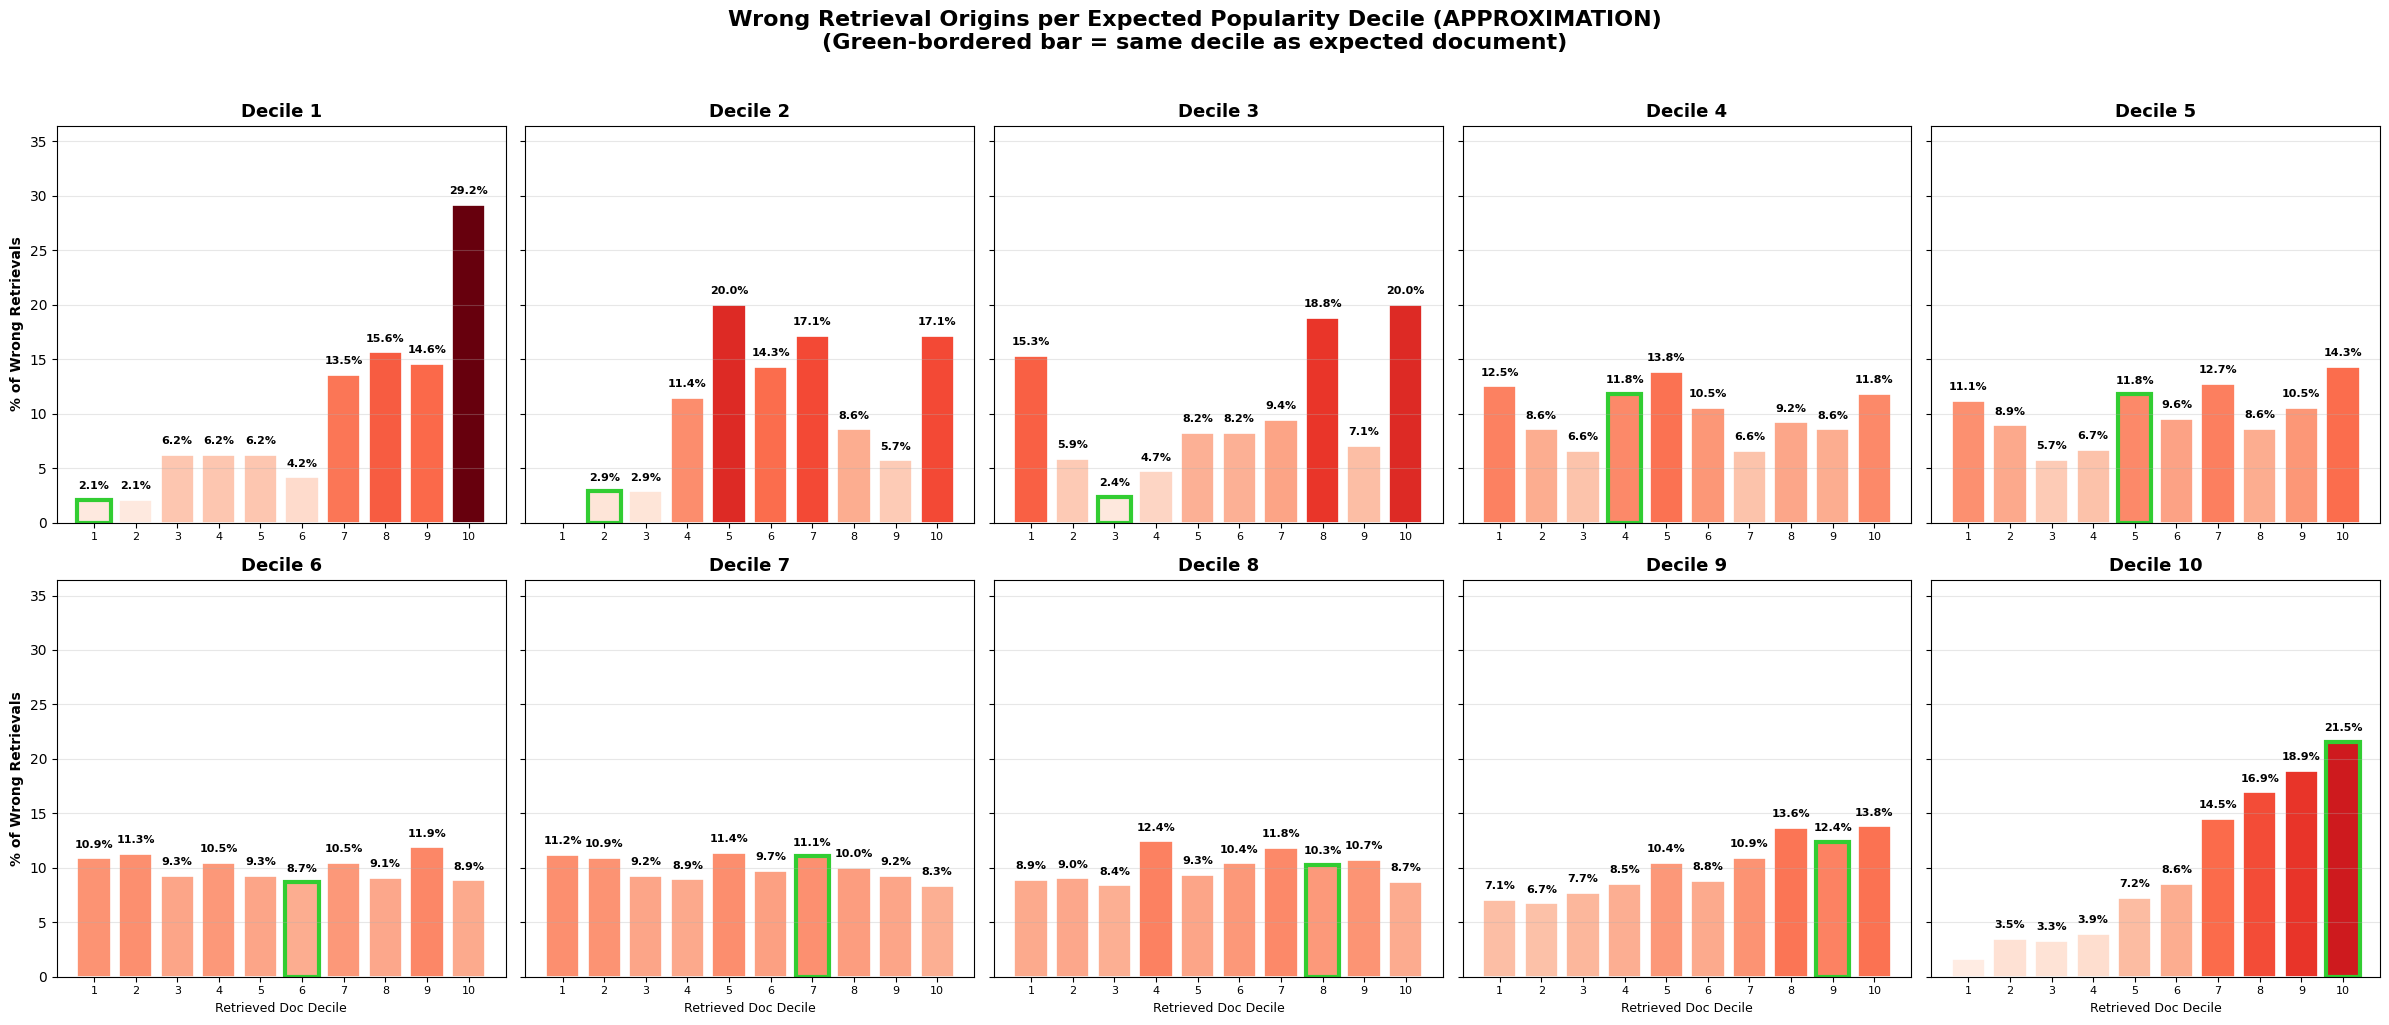

✓ Saved per-decile wrong retrieval origins to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/wrong_retrieval_origins_per_decile.png


In [ ]:
# ============================================================================
# Per-Decile Wrong Retrieval Origin Analysis
# ============================================================================
# One chart per popularity decile showing where wrongly retrieved docs came from

analysis_strategy = ALL_STRATEGIES[0]
analysis_df = results_by_strategy[analysis_strategy]

# Build the heatmap matrix (reuse logic from bias analysis)
heatmap_data = np.zeros((10, 10))
for _, row in analysis_df.iterrows():
    expected_dec = int(row['pop_decile'])
    wrong_pops = row['wrong_docs_popularities']
    if wrong_pops:
        for wp in wrong_pops:
            wrong_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
            if not pd.isna(wrong_dec):
                heatmap_data[expected_dec, int(wrong_dec)] += 1

# Normalize each row to percentages
row_sums = heatmap_data.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_pct = heatmap_data / row_sums * 100

# Create 2x5 grid — one bar chart per expected decile
fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharey=True)
axes_flat = axes.flatten()

cmap = plt.cm.Reds
norm = plt.Normalize(vmin=0, vmax=heatmap_pct.max())

for decile in range(10):
    ax = axes_flat[decile]
    values = heatmap_pct[decile]
    colors = [cmap(norm(v)) for v in values]

    bars = ax.bar(np.arange(1, 11), values, color=colors, edgecolor='white', linewidth=1.2)

    # Highlight the "same decile" bar with a green edge
    bars[decile].set_edgecolor('limegreen')
    bars[decile].set_linewidth(3)

    # Value labels on bars > 2%
    for i, val in enumerate(values):
        if val > 2:
            ax.text(i + 1, val + 0.8, f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

    ax.set_title(f'Decile {decile + 1}', fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels(range(1, 11), fontsize=8)
    ax.set_ylim(0, heatmap_pct.max() * 1.25)
    ax.grid(axis='y', alpha=0.3)

    if decile % 5 == 0:
        ax.set_ylabel('% of Wrong Retrievals', fontsize=10, fontweight='bold')
    if decile >= 5:
        ax.set_xlabel('Retrieved Doc Decile', fontsize=9)

fig.suptitle(
    f'Wrong Retrieval Origins per Expected Popularity Decile ({analysis_strategy.upper()})\n'
    '(Green-bordered bar = same decile as expected document)',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "wrong_retrieval_origins_per_decile.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved per-decile wrong retrieval origins to {RESULTS_DIR / 'wrong_retrieval_origins_per_decile.png'}")

In [ ]:
# ============================================================================
# 🔎 VISUAL INSPECTION: Questions & Retrieved Text (DataFrame Export)
# ============================================================================

# Settings
NUM_SAMPLES = 10  # Increased for better CSV coverage
TOP_K_DISPLAY = 5

print(f"Sampling {NUM_SAMPLES} random questions to inspect top {TOP_K_DISPLAY} results per strategy...\n")

# Pick random questions
sample_subset = qa_df.sample(n=min(NUM_SAMPLES, len(qa_df)))
inspection_data = []

for i, row in enumerate(sample_subset.itertuples(), 1):
    q_text = row.question_text
    true_id = str(row.wikipedia_id).strip()
    true_title = getattr(row, "wikipedia_title", "Unknown")
    
    # Print brief progress
    print(f"Processing Sample Q{i}: {q_text[:50]}...")
    
    for strategy in ALL_STRATEGIES:
        try:
            # Temporarily switch strategy
            with service._strategy_context(strategy):
                results = service.retrieve_documents_with_scores(q_text, top_k=TOP_K_DISPLAY)
                
                for rank, (doc, score) in enumerate(results, 1):
                    # Metadata extraction
                    doc_id = str(doc.metadata.get("wikipedia_id", doc.metadata.get("id", ""))).strip()
                    title = doc.metadata.get("wikipedia_title", doc.metadata.get("title", "No Title"))
                    pop = doc.metadata.get("popularity_avg", None)
                    
                    # Match check
                    is_match = (doc_id == true_id)
                    
                    # Clean snippet
                    snippet = doc.page_content.replace("\n", " ").replace("  ", " ")[:300]
                    
                    inspection_data.append({
                        "sample_idx": i,
                        "question": q_text,
                        "expected_title": true_title,
                        "expected_id": true_id,
                        "strategy": strategy,
                        "rank": rank,
                        "score": score,
                        "is_match": is_match,
                        "retrieved_title": title,
                        "retrieved_id": doc_id,
                        "popularity": pop,
                        "snippet": snippet
                    })
                    
        except Exception as e:
            print(f"   Error in strategy {strategy}: {e}")
            import traceback
            traceback.print_exc()

# Create DataFrame
inspection_df = pd.DataFrame(inspection_data)

# Save to CSV
output_path = RESULTS_DIR / "inspection_samples.csv"
inspection_df.to_csv(output_path, index=False)
print(f"\n✅ Inspection data saved to: {output_path}")

# Display a formatted view of the first question's results
print("\nFirst Question Results Preview:")
first_sample = inspection_df[inspection_df["sample_idx"] == 1]
display_cols = ["strategy", "rank", "score", "is_match", "retrieved_title", "snippet"]

display(first_sample[display_cols].style.background_gradient(subset=['score'], cmap='Blues'))

Sampling 10 random questions to inspect top 5 results per strategy...

Processing Sample Q1: when did sunday shopping start in nova scotia...
Processing Sample Q2: who is the chief judge of delta state...
Processing Sample Q3: infections that originate in hospitals are known a...
Processing Sample Q4: the clayton antitrust act of 1914 and the robinson...
Processing Sample Q5: who was the first person jax killed on soa...
Processing Sample Q6: who won the mens doubles at australian open 2018...
Processing Sample Q7: which step of eukaryotic mrna processing helps in ...
Processing Sample Q8: who sings you're gonna ruin my bad reputation...
Processing Sample Q9: who won the australian open women's title...
Processing Sample Q10: what is the current edition of the united states c...

✅ Inspection data saved to: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/evaluation_results/inspection_samples.csv

First Question Results Preview:


,strategy,rank,score,is_match,retrieved_title,snippet
0,approximation,1,0.928996,False,Sunday shopping,"passage: Section::::Sunday shopping by continent.:North America.:Canada.:Alberta. In 1984, the province of Alberta granted municipalities the right to allow, or prohibit, retail stores opening on Sundays. By the end of 1984, some stores in Edmonton were open on Sundays, but the controversy over Sund"
1,approximation,2,0.925609,False,Sunday shopping,"passage: In June 1990, the Supreme Court of Ontario found the act to be unconstitutional. As a result, Ontario had nine months of open-wide Sunday shopping, until the Ontario Court of Appeal's reversal of the decision in March 1991. However, public opposition to Sunday closing continued to rise. Bow"
2,approximation,3,0.921092,False,Sunday shopping,"passage: On 23 June 2006, the Premier of Nova Scotia, Rodney MacDonald, announced new limits on Sunday shopping as a means to honour the wishes of voters in the 2004 plebiscite. The proposed new regulations prohibited grocers and other retailers from opening if they reconfigured their businesses as"
3,approximation,4,0.920206,False,Sunday shopping,"passage: Newfoundland and Labrador lifted restrictions on retail stores operating on Sundays starting on January 1, 1998. Section::::Sunday shopping by continent.:North America.:United States. Many states in the United States have reduced hours of operation on Sundays in some form or another. A few"
4,approximation,5,0.917773,False,Sundae,"passage: Section::::Contested origins.:Ithaca, New York in 1892. Supporting Ithacas claim to be ""the birthplace of the ice cream sundae"", researchers at The History Center in Tompkins County, New York, provide an account of how the sundae came to be: On Sunday, April 3, 1892, in Ithaca, John M. Scot"
5,bm25,1,38.399742,False,Pete Luckett,"passage: Section::::Impact on retailing in Nova Scotia. In 1999, Luckett made headlines when he won a court battle against the Government of Nova Scotia when he sought to keep his Bedford store open on Sunday. To circumvent Nova Scotia's Sunday shopping laws, Luckett registered sections of his Bedfo"
6,bm25,2,37.830173,True,2004 Nova Scotia Sunday shopping plebiscite,"passage: 2004 Nova Scotia Sunday shopping plebiscite A plebiscite on Sunday shopping was held on October 16, 2004 (to coincide with municipal elections) in Nova Scotia. The vote was 54.90% for the ""no"" side, meaning that a Sunday shopping ban remained in place. The issue pitted the municipality of H"
7,bm25,3,36.174700,False,Sunday shopping,"passage: Section::::Sunday shopping by continent.:North America.:Canada.:Alberta. In 1984, the province of Alberta granted municipalities the right to allow, or prohibit, retail stores opening on Sundays. By the end of 1984, some stores in Edmonton were open on Sundays, but the controversy over Sund"
8,bm25,4,35.536390,False,John Hamm,"passage: In the 2003 election, Hamm's Progressive Conservatives were reduced to a minority government. The main issue in that election was the increasing cost of car insurance and whether Nova Scotia should begin to allow general Sunday shopping. Despite the minority government, Hamm's government wa"
9,bm25,5,33.997364,False,Sunnyside Mall,"passage: Sunnyside Mall The Sunnyside Mall is a Canadian shopping mall in Bedford, Nova Scotia. Section::::See also. BULLET::::- List of Canada's largest shopping malls BULLET::::- List of shopping malls in Canada BULLET::::- Bedford, Nova Scotia Section::::External links. BULLET::::- Nova Scotia -"
